# Task 1

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('terrorism.csv')
df = df[['country_txt', 'region_txt', 'latitude', 'longitude']]
df.shape

(2997, 4)

In [3]:
df.dropna(axis=0)

,country_txt,region_txt,latitude,longitude
0,United States,North America,44.405705,-85.714454
1,Colombia,South America,4.667128,-74.106056
2,Colombia,South America,7.198606,-75.341218
3,United States,North America,38.232471,-122.644448
4,United States,North America,39.103175,-84.511981
...,...,...,...,...
2992,Mexico,North America,17.949243,-94.916882
2993,Colombia,South America,7.745807,-76.556143
2994,United States,North America,40.262772,-76.881107
2995,United States,North America,40.261864,-76.880913


In [4]:
site = df.sample(12, random_state=8)
site = site.rename(columns = {'country_txt':'country', 'region_txt': 'region'})
site = site.reset_index(drop=True)

In [5]:
site["site_name"] = "Site " + (site.index + 1).astype(str)
site

,country,region,latitude,longitude,site_name
0,Venezuela,South America,7.532824,-71.999407,Site 1
1,Colombia,South America,1.807981,-78.768396,Site 2
2,United States,North America,35.084180,-106.648639,Site 3
3,Colombia,South America,1.641284,-77.734463,Site 4
4,Colombia,South America,7.301376,-72.492754,Site 5
5,Colombia,South America,6.963234,-71.881599,Site 6
6,United States,North America,40.697132,-73.931351,Site 7
7,Mexico,North America,27.480024,-99.510535,Site 8
8,Colombia,South America,2.519314,-74.753891,Site 9
9,United States,North America,38.853889,-94.781111,Site 10


# Task 2

In [6]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Latitude')

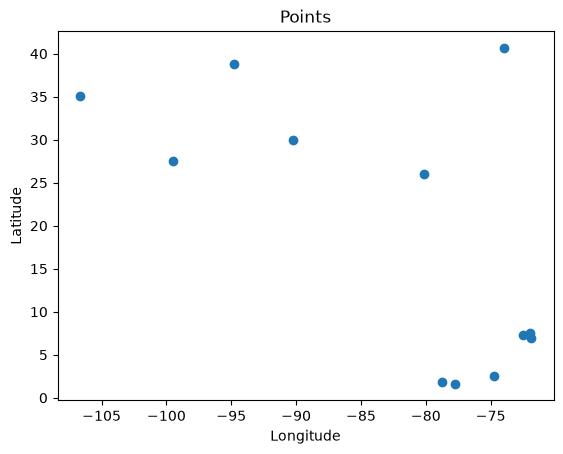

In [7]:
plt.scatter(site['longitude'], site['latitude'])
plt.title('Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

It's missing a map to show where these points actually are in space

# Task 3

In [8]:
import folium

In [9]:
map = folium.Map([10, -70], zoom_start=3)
map

In [10]:
for index, row in site.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=row['site_name'], tooltip=row['country']).add_to(map)
map

In [11]:
import geopandas as gpd

In [12]:
points = gpd.points_from_xy(site['longitude'], site['latitude'])
site_gdf = gpd.GeoDataFrame(site, geometry=points)
site_gdf

,country,region,latitude,longitude,site_name,geometry
0,Venezuela,South America,7.532824,-71.999407,Site 1,POINT (-71.99941 7.53282)
1,Colombia,South America,1.807981,-78.768396,Site 2,POINT (-78.7684 1.80798)
2,United States,North America,35.084180,-106.648639,Site 3,POINT (-106.64864 35.08418)
3,Colombia,South America,1.641284,-77.734463,Site 4,POINT (-77.73446 1.64128)
4,Colombia,South America,7.301376,-72.492754,Site 5,POINT (-72.49275 7.30138)
5,Colombia,South America,6.963234,-71.881599,Site 6,POINT (-71.8816 6.96323)
6,United States,North America,40.697132,-73.931351,Site 7,POINT (-73.93135 40.69713)
7,Mexico,North America,27.480024,-99.510535,Site 8,POINT (-99.51054 27.48002)
8,Colombia,South America,2.519314,-74.753891,Site 9,POINT (-74.75389 2.51931)
9,United States,North America,38.853889,-94.781111,Site 10,POINT (-94.78111 38.85389)


In [13]:
ven_point = site_gdf.iloc[0]['geometry']
ven_buffer = ven_point.buffer(2)
folium.Circle(location=[10.4828, -66.9621], radius=1000, color='blue', fill=True).add_to(map)
map

In [14]:
chmap = folium.Map([10, -70], zoom_start=3)
chmap

In [15]:
na_gdf = site_gdf[site_gdf['region']=='North America']
na_gdf

,country,region,latitude,longitude,site_name,geometry
2,United States,North America,35.084180,-106.648639,Site 3,POINT (-106.64864 35.08418)
6,United States,North America,40.697132,-73.931351,Site 7,POINT (-73.93135 40.69713)
7,Mexico,North America,27.480024,-99.510535,Site 8,POINT (-99.51054 27.48002)
9,United States,North America,38.853889,-94.781111,Site 10,POINT (-94.78111 38.85389)
10,United States,North America,29.984368,-90.257301,Site 11,POINT (-90.2573 29.98437)
11,United States,North America,26.071231,-80.145668,Site 12,POINT (-80.14567 26.07123)


In [16]:
na_points = na_gdf.unary_union
na_hull = na_points.convex_hull
folium.GeoJson(na_hull).add_to(chmap)
chmap

/var/folders/6q/gcvrft1x6vqd8ns1bjj5cz6w0000gn/T/ipykernel_59614/4144390532.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  na_points = na_gdf.unary_union


In [18]:
sa_gdf = site_gdf[site_gdf['region']=='South America']

sa_gdf

,country,region,latitude,longitude,site_name,geometry
0,Venezuela,South America,7.532824,-71.999407,Site 1,POINT (-71.99941 7.53282)
1,Colombia,South America,1.807981,-78.768396,Site 2,POINT (-78.7684 1.80798)
3,Colombia,South America,1.641284,-77.734463,Site 4,POINT (-77.73446 1.64128)
4,Colombia,South America,7.301376,-72.492754,Site 5,POINT (-72.49275 7.30138)
5,Colombia,South America,6.963234,-71.881599,Site 6,POINT (-71.8816 6.96323)
8,Colombia,South America,2.519314,-74.753891,Site 9,POINT (-74.75389 2.51931)


In [19]:
sa_points = sa_gdf.unary_union
sa_hull = sa_points.convex_hull
folium.GeoJson(sa_hull).add_to(chmap)
chmap

/var/folders/6q/gcvrft1x6vqd8ns1bjj5cz6w0000gn/T/ipykernel_59614/4097500579.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sa_points = sa_gdf.unary_union


A convex hull is taking every point you give it, then making a polygon out of the points that contain every point.